In [3]:
#Cargar Montone Convex Soberanos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CMT_TENORS = [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
MIN_BONDS = 3

def mc_node_forwards(t, f_disc):
    n = len(t)
    f = np.zeros(n)
    for i in range(1, n - 1):
        h_l = t[i] - t[i - 1]
        h_r = t[i + 1] - t[i]
        f[i] = (f_disc[i - 1] * h_r + f_disc[i] * h_l) / (h_l + h_r)
    f[0] = f_disc[0] - 0.5 * (f[1] - f_disc[0])
    f[-1] = f_disc[-1] - 0.5 * (f[-2] - f_disc[-1])
    return np.maximum(f, 1e-6)

def mc_correct_fwd(f0, fd, f1):
    etas = np.linspace(0.01, 0.99, 300)
    f_cur = (
    f0 * (1 - 4 * etas + 3 * etas**2)
        + fd * 6 * etas * (1 - etas)
        + f1 * etas * (-2 + 3 * etas)
    )
    if f_cur.min() >= 0:
        return f0, fd, f1
    g = (
        f0 * (1 - 4 * etas + 3 * etas**2)
        + f1 * etas * (-2 + 3 * etas)
    )
    w = 6 * etas * (1 - etas)
    mask = w > 1e-12
    fd_new = max(fd, np.max(-g[mask] / w[mask]) + 1e-8)
    return max(f0, 1e-6), fd_new, max(f1, 1e-6)

def mc_yield_at(t_query, t, y_dec, Q, f_disc, f_node):
    hit = np.where(np.abs(t - t_query) < 1e-9)[0]
    if len(hit):
        return float(y_dec[hit[0]] * 100)
    if t_query < t[0] or t_query > t[-1]:
        return np.nan
    i = int(np.clip(int(np.searchsorted(t, t_query, side="right")) - 1, 0, len(t) - 2))
    t0 = t[i]
    t1 = t[i + 1]
    h = t1 - t0
    eta = (t_query - t0) / h
    f0, fd, f1 = mc_correct_fwd(f_node[i], f_disc[i], f_node[i + 1])
    Q_t = Q[i] + h * (
        f0 * (eta - 2 * eta**2 + eta**3)
        + fd * (3 * eta**2 - 2 * eta**3)
        + f1 * (-eta**2 + eta**3)
    )
    return float((Q_t / t_query) * 100)

def build_cmt(df_clean, tenors=CMT_TENORS, min_bonds=MIN_BONDS):
    records = []
    skipped = 0
    first_error = None
    df_work = df_clean.copy()
    df_work["Fecha"] = pd.to_datetime(df_work["Fecha"])
    for date, grp in df_work.groupby("Fecha"):
        grp = grp.dropna(subset=["Maturity", "FV.Rate"]).sort_values("Maturity").drop_duplicates("Maturity")
        if len(grp) < min_bonds:
            skipped += 1
            continue
        t_raw = grp["Maturity"].values
        y_raw = grp["FV.Rate"].values
        t_min = t_raw.min()
        t_max = t_raw.max()
        try:
            idx = np.argsort(t_raw)
            t_s = t_raw[idx]
            y_dec = y_raw[idx] / 100.0
            Q = y_dec * t_s
            f_disc = np.diff(Q) / np.diff(t_s)
            f_node = mc_node_forwards(t_s, f_disc)
            row = {"Fecha": date}
            for tau in tenors:
                if t_min <= tau <= t_max:
                    row[f"{tau}Y"] = round(mc_yield_at(tau, t_s, y_dec, Q, f_disc, f_node), 4)
                else:
                    row[f"{tau}Y"] = np.nan
            records.append(row)
        except Exception as e:
            if first_error is None:
                first_error = str(e)
            skipped += 1
    if len(records) == 0:
        print(f"ERROR: 0 records built. skipped={skipped}. First error: {first_error}")
        return pd.DataFrame()
    df_cmt = pd.DataFrame(records).sort_values("Fecha").reset_index(drop=True)
    df_cmt["Fecha"] = pd.to_datetime(df_cmt["Fecha"])
    print(f"CMT built: {len(df_cmt):,} dates | skipped: {skipped:,}")
    return df_cmt



print("functions loaded OK")
print("test:", mc_yield_at(8, np.array([6.0,10.0,15.0]), np.array([0.07,0.075,0.078]), np.array([0.07,0.075,0.078])*np.array([6.0,10.0,15.0]), np.diff(np.array([0.07,0.075,0.078])*np.array([6.0,10.0,15.0]))/np.diff(np.array([6.0,10.0,15.0])), mc_node_forwards(np.array([6.0,10.0,15.0]), np.diff(np.array([0.07,0.075,0.078])*np.array([6.0,10.0,15.0]))/np.diff(np.array([6.0,10.0,15.0])))))

functions loaded OK
test: 7.30625


In [ ]:
# # UST Curve Regime Model

# Classifies daily curve moves into 6 regimes based on realized changes

# in 2-tenor spreads over a rolling lookback window.

# 

# **Regimes:**

# - Bull Steepener / Bear Steepener

# - Bull Flattener / Bear Flattener

# - Steepener Twist / Flattener Twist

# Cell 1 – Imports & Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# – Load data –

# 2 files neeeded
#USTs90s26s.csv
#this one is the UST CMT curve  with nodes of ['1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']

#dfsobs.csv
#this is a database of Closing Runs (yields) for Peru PEN Sovereigns (Soberanos) which are  interpolated 
# via monotone convex functions as seen on the first cell of all (#Cargar Montone Convex Soberanos)


#Load USTs CMT

PATH = r"R:/RScripts/PCA Tools Frodo/PCA Tools Frodo/USTs90s26s.csv"

df = pd.read_csv(PATH)

# Parse dates: Fecha is string mm/dd/yyyy

df["Fecha"] = pd.to_datetime(df["Fecha"], format="%m/%d/%Y")
df = df.sort_values("Fecha").reset_index(drop=True)
df = df.set_index("Fecha")

# Rename columns to strip any whitespace

df.columns = df.columns.str.strip()

# Quick sanity check

print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

# %% Cell 2 – Compute Spreads

# All standard curve spreads (in bps, assuming yields are in %)

# If your yields are already in bps, remove the * 100

spreads = pd.DataFrame(index=df.index)

spreads["2s5s"]   = (df["5Y"]  - df["2Y"])  * 100
spreads["2s10s"]  = (df["10Y"] - df["2Y"])  * 100
spreads["2s30s"]  = (df["30Y"] - df["2Y"])  * 100
spreads["5s10s"]  = (df["10Y"] - df["5Y"])  * 100
spreads["5s30s"]  = (df["30Y"] - df["5Y"])  * 100
spreads["10s30s"] = (df["30Y"] - df["10Y"]) * 100

# Store yields in bps too for regime logic

yields_bps = df * 100

print("Spread summary (bps):")
spreads.tail()

#Load and Construct Soberanos CMT

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sklearn

### Importar data
# Acá cargar data de un .csv o cargar data de BBG si es posible. 


file = 'R:/RScripts/PCA Tools Frodo/PCA Tools Frodo/dfsobs.csv'
df = pd.read_csv(file, parse_dates = ["Fecha"])
df["Fecha"] = pd.to_datetime(df["Fecha"], errors = "coerce", format = "%d/%m/%Y")

# Se puede revisar por fecha:
# print(df[df["date"] == pd.to_datetime("03/08/2015", format = "%d/%m/%Y")])

# Dropear combinaciones fecha-instrumento con bid y offer NA
df_clean = df.dropna(subset = ["Bid","Offer"], how = "all")

df_clean = df_clean.copy()

df_clean["FV.Rate"] = np.where(
  (df_clean["Bid"] <= 0) | pd.isna(df_clean["Bid"]), 
    df_clean["Offer"] + 0.01,
  np.where(
  (df_clean["Offer"] <= 0) | pd.isna(df_clean["Offer"]), 
    df_clean["Bid"] - 0.01, 
    (df_clean["Bid"] + df_clean["Offer"])/2
  )
)
df_clean["Fecha"] = pd.to_datetime(df_clean["Fecha"], errors = "coerce", format = "%d/%m/%Y")

df_clean = df_clean[df_clean["Fecha"] >= "2017-01-02"]


df_cmt = build_cmt(df_clean)

print(df_cmt.isna().sum())  # Should be all zeros or very few    

#dropping nan
df_cmt = df_cmt.dropna()

print(df_cmt.head())


FileNotFoundError: [Errno 2] No such file or directory: 'R:/RScripts/PCA Tools Frodo/PCA Tools Frodo/USTs90s26s.csv'

In [111]:
LOOKBACK = 5    # business days for regime detection
WEEKS = 20       # weeks of data to display in chart

In [112]:
def classify_regime(df_yields_bps, short_tenor, long_tenor, lookback):
    result = pd.DataFrame(index=df_yields_bps.index)

    # Spread level in bps (for plotting)
    result["spread_level"] = df_yields_bps[long_tenor] - df_yields_bps[short_tenor]

    # Changes over lookback window
    result["short_chg"]  = df_yields_bps[short_tenor].diff(lookback)
    result["long_chg"]   = df_yields_bps[long_tenor].diff(lookback)
    result["spread_chg"] = result["long_chg"] - result["short_chg"]

    result = result.dropna()

    # Vectorized regime assignment
    conditions = [
        # Steepeners (spread_chg > 0)
        (result["spread_chg"] > 0) & (result["short_chg"] <= 0) & (result["long_chg"] <= 0),
        (result["spread_chg"] > 0) & (result["short_chg"] > 0)  & (result["long_chg"] > 0),
        (result["spread_chg"] > 0) & (result["short_chg"] <= 0) & (result["long_chg"] > 0),

        # Flatteners (spread_chg < 0)
        (result["spread_chg"] < 0) & (result["short_chg"] <= 0) & (result["long_chg"] <= 0),
        (result["spread_chg"] < 0) & (result["short_chg"] > 0)  & (result["long_chg"] > 0),
        (result["spread_chg"] < 0) & (result["short_chg"] > 0)  & (result["long_chg"] <= 0),
    ]

    labels = [
        "Bull Steepener",
        "Bear Steepener",
        "Steepener Twist",
        "Bull Flattener",
        "Bear Flattener",
        "Flattener Twist",
    ]

    result["regime"] = np.select(conditions, labels, default="")

    # Forward-fill any NaN (edge case: both changes exactly 0)
    result["regime"] = result["regime"].replace("", np.nan)
    result["regime"] = result["regime"].ffill()

    # If the very first row is NaN, backfill it
    result["regime"] = result["regime"].bfill()

    return result


# – Run for 2s10s with lookback = 20 –


regimes = classify_regime(yields_bps, "2Y", "10Y", lookback=LOOKBACK)

# Check regime distribution

print(f"Regime classification (2s10s, lookback={LOOKBACK}d):\n")
counts = regimes["regime"].value_counts()
print(counts)
print(f"\nTotal obs: {len(regimes)}")
print(f"Unique regimes: {regimes["regime"].nunique()}")


Regime classification (2s10s, lookback=5d):

regime
Bull Flattener     2381
Bear Steepener     1894
Bull Steepener     1576
Bear Flattener     1398
Flattener Twist     935
Steepener Twist     859
Name: count, dtype: int64

Total obs: 9043
Unique regimes: 6


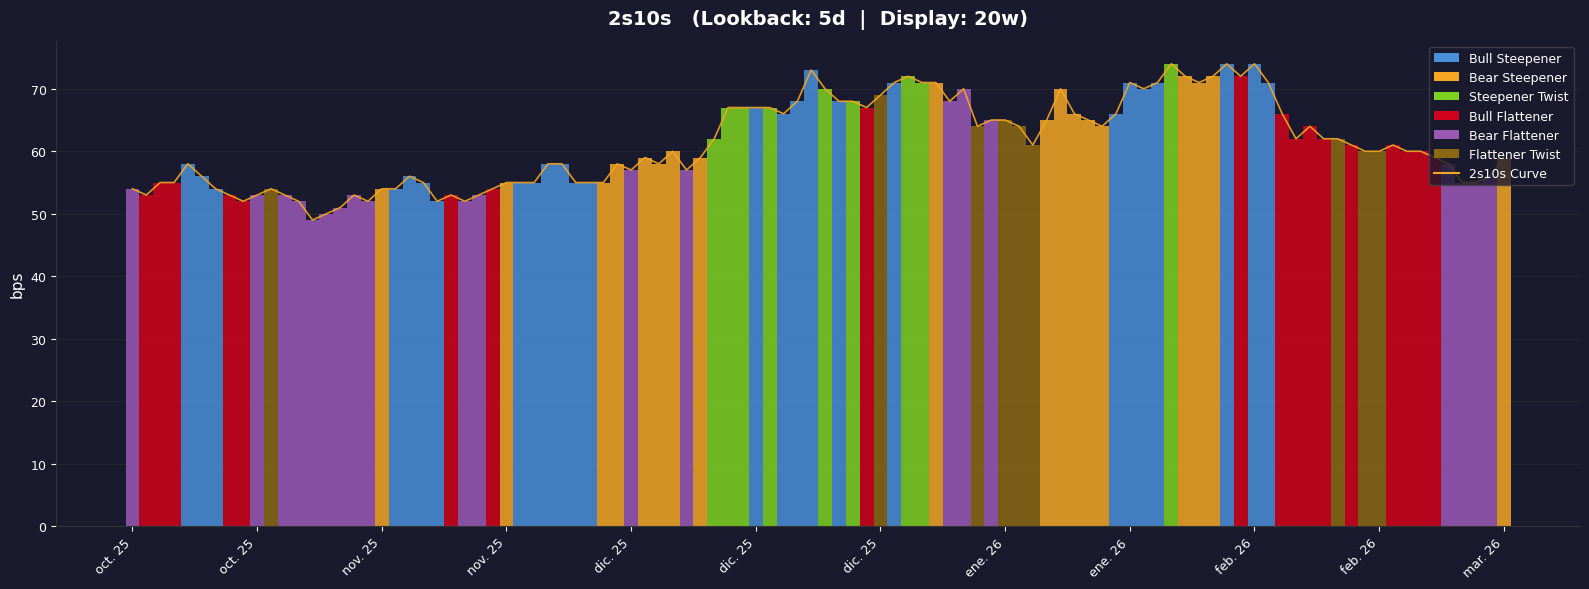

In [113]:
# %% Cell 4 -- Regime Chart (FIXED: no weekend gaps)
def plot_regime_chart(regimes_df, spread_name, weeks, lookback):
    n_days = weeks * 5
    plot_data = regimes_df.iloc[-n_days:].copy()
    plot_data = plot_data.reset_index()

    regime_colors = {
        "Bull Steepener":   "#4A90D9",
        "Bear Steepener":   "#F5A623",
        "Steepener Twist":  "#7ED321",
        "Bull Flattener":   "#D0021B",
        "Bear Flattener":   "#9B59B6",
        "Flattener Twist":  "#8B6914",
    }

    bar_colors = plot_data["regime"].map(regime_colors)

    fig, ax = plt.subplots(figsize=(16, 6))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#1a1a2e")

    # Plot against integer index, not dates
    x = np.arange(len(plot_data))

    ax.bar(
        x,
        plot_data["spread_level"],
        color=bar_colors,
        width=1.0,
        alpha=0.85,
        edgecolor="none",
    )

    ax.plot(
        x,
        plot_data["spread_level"],
        color="#F5A623",
        linewidth=1.2,
        alpha=0.9,
    )

    # X-axis: show ~12 date labels evenly spaced
    n_ticks = min(12, len(plot_data))
    tick_idx = np.linspace(0, len(plot_data) - 1, n_ticks, dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(
        [plot_data["Fecha"].iloc[i].strftime("%b %y") for i in tick_idx],
        rotation=45,
        ha="right",
    )

    ax.set_title(
        f"{spread_name}   (Lookback: {lookback}d  |  Display: {weeks}w)",
        color="white", fontsize=14, fontweight="bold", pad=12,
    )
    ax.set_ylabel("bps", color="white", fontsize=11)

    ax.tick_params(colors="white", labelsize=9)
    ax.spines["bottom"].set_color("#333")
    ax.spines["left"].set_color("#333")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.yaxis.grid(True, color="#333", linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    from matplotlib.patches import Patch
    legend_order = [
        "Bull Steepener", "Bear Steepener", "Steepener Twist",
        "Bull Flattener", "Bear Flattener", "Flattener Twist",
    ]
    legend_elements = [
        Patch(facecolor=regime_colors[r], label=r) for r in legend_order
    ]
    legend_elements.append(
        plt.Line2D([0], [0], color="#F5A623", linewidth=1.5, label=f"{spread_name} Curve")
    )
    ax.legend(
        handles=legend_elements,
        loc="upper right",
        fontsize=9,
        facecolor="#1a1a2e",
        edgecolor="#444",
        labelcolor="white",
    )

    plt.tight_layout()
    plt.show()
    return fig

fig = plot_regime_chart(regimes, "2s10s", weeks=WEEKS, lookback=LOOKBACK)


In [114]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go

# Spread selector options
spread_options = {
    "2s5s":   ("2Y", "5Y"),
    "2s10s":  ("2Y", "10Y"),
    "2s30s":  ("2Y", "30Y"),
    "5s10s":  ("5Y", "10Y"),
    "5s30s":  ("5Y", "30Y"),
    "10s30s": ("10Y", "30Y"),
}

def compute_streak_days(regimes_series):
    """For each row, how many consecutive days this regime has been active."""
    streaks = []
    count = 1
    prev = regimes_series.iloc[0]
    streaks.append(count)
    for i in range(1, len(regimes_series)):
        if regimes_series.iloc[i] == prev:
            count += 1
        else:
            count = 1
            prev = regimes_series.iloc[i]
        streaks.append(count)
    return streaks

def compute_avg_durations(regimes_series):
    """Average streak length per regime over the full series."""
    streaks = []
    current_regime = regimes_series.iloc[0]
    current_len = 1
    for i in range(1, len(regimes_series)):
        if regimes_series.iloc[i] == current_regime:
            current_len += 1
        else:
            streaks.append((current_regime, current_len))
            current_regime = regimes_series.iloc[i]
            current_len = 1
    streaks.append((current_regime, current_len))

    streak_df = pd.DataFrame(streaks, columns=["regime", "duration"])
    avg_dur = streak_df.groupby("regime")["duration"].mean()
    return avg_dur

def build_chart(spread_name, lookback, weeks, avg_window_years):
    short_t, long_t = spread_options[spread_name]
    reg = classify_regime(yields_bps, short_t, long_t, lookback)

    # Determine avg duration window
    if avg_window_years == "Max":
        reg_for_avg = reg.copy()
    else:
        n_days_avg = int(float(avg_window_years) * 252)
        reg_for_avg = reg.iloc[-n_days_avg:]

    avg_dur = compute_avg_durations(reg_for_avg["regime"])

    # Trim to display window
    n_days = weeks * 5
    plot_data = reg.iloc[-n_days:].copy()
    plot_data = plot_data.reset_index()

    # Compute streaks on display window (but need context from before)
    # Recompute on full series then trim
    full_streaks = compute_streak_days(reg["regime"])
    reg["streak_days"] = full_streaks
    plot_data = reg.iloc[-n_days:].copy()
    plot_data = plot_data.reset_index()

    # Distance to average
    plot_data["avg_duration"] = plot_data["regime"].map(avg_dur).round(1)
    plot_data["dist_to_avg"] = (
        plot_data["streak_days"] - plot_data["avg_duration"]
    ).round(1)

    # Colors
    regime_colors = {
        "Bull Steepener":   "#4A90D9",
        "Bear Steepener":   "#F5A623",
        "Steepener Twist":  "#7ED321",
        "Bull Flattener":   "#D0021B",
        "Bear Flattener":   "#9B59B6",
        "Flattener Twist":  "#8B6914",
    }

    bar_colors = plot_data["regime"].map(regime_colors).tolist()

    # Hover text
    hover_text = []
    for _, row in plot_data.iterrows():
        txt = (
            f"Date: {row['Fecha'].strftime('%d %b %Y')}<br>"
            f"Spread: {row['spread_level']:.1f} bps<br>"
            f"Regime: {row['regime']}<br>"
            f"Days in regime: {int(row['streak_days'])}<br>"
            f"Avg duration: {row['avg_duration']:.1f}d<br>"
            f"Dist to avg: {row['dist_to_avg']:+.1f}d"
        )
        hover_text.append(txt)

    # Build Plotly figure
    fig = go.Figure()

    # Bars
    fig.add_trace(go.Bar(
        x=plot_data["Fecha"],
        y=plot_data["spread_level"],
        marker_color=bar_colors,
        hovertext=hover_text,
        hoverinfo="text",
        name="Spread Level",
        showlegend=False,
    ))

    # Line overlay
    fig.add_trace(go.Scatter(
        x=plot_data["Fecha"],
        y=plot_data["spread_level"],
        mode="lines",
        line=dict(color="#F5A623", width=1.5),
        hoverinfo="skip",
        name=f"{spread_name} Curve",
        showlegend=True,
    ))

    # Invisible traces for legend color boxes
    for regime_name in [
        "Bull Steepener", "Bear Steepener", "Steepener Twist",
        "Bull Flattener", "Bear Flattener", "Flattener Twist",
    ]:
        fig.add_trace(go.Bar(
            x=[None], y=[None],
            marker_color=regime_colors[regime_name],
            name=regime_name,
            showlegend=True,
        ))

    window_label = (
        f"Max (1990)" if avg_window_years == "Max"
        else f"{avg_window_years}y"
    )

    fig.update_layout(
        title=dict(
            text=(
                f"{spread_name}   "
                f"(Lookback: {lookback}d  |  "
                f"Display: {weeks}w  |  "
                f"Avg Window: {window_label})"
            ),
            font=dict(color="white", size=14),
        ),
        paper_bgcolor="#1a1a2e",
        plot_bgcolor="#1a1a2e",
        font=dict(color="white"),
        yaxis=dict(
            title="bps",
            gridcolor="#333",
            gridwidth=0.5,
        ),
        xaxis=dict(
            gridcolor="#333",
            gridwidth=0.5,
            rangeslider=dict(visible=False),
        ),
        legend=dict(
            bgcolor="rgba(26,26,46,0.9)",
            bordercolor="#444",
            borderwidth=1,
            font=dict(size=10),
        ),
        dragmode="zoom",
        height=500,
        bargap=0,
    )

    fig.show()

    # Print stats
    print()
    print("=" * 60)
    print(f"REGIME STATS (last {weeks}w)")
    print("=" * 60)
    stats = regime_summary(plot_data, weeks=None)
    print(stats.to_string())

# -- Widgets --
w_spread = widgets.Dropdown(
    options=list(spread_options.keys()),
    value="2s10s",
    description="Spread:",
    style={"description_width": "80px"},
)

w_lookback = widgets.Text(
    value="20",
    description="Lookback (d):",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="200px"),
)

w_weeks = widgets.Text(
    value="52",
    description="Display (w):",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="200px"),
)

w_avg = widgets.Text(
    value="3",
    description="Avg Window (y):",
    style={"description_width": "110px"},
    layout=widgets.Layout(width="220px"),
)

w_button = widgets.Button(
    description="Update",
    button_style="info",
    layout=widgets.Layout(width="100px"),
)

output = widgets.Output()

def on_click(_):
    # Validate lookback
    try:
        lb = int(w_lookback.value)
        lb = max(5, min(180, lb))
    except ValueError:
        lb = 20

    # Validate weeks
    try:
        wk = int(w_weeks.value)
        wk = max(1, min(52, wk))
    except ValueError:
        wk = 52

    # Validate avg window
    avg_val = w_avg.value.strip().lower()
    if avg_val == "max":
        avg_w = "Max"
    else:
        try:
            avg_w = float(avg_val)
            avg_w = max(0.25, avg_w)
            avg_w = str(avg_w)
        except ValueError:
            avg_w = "3"

    with output:
        clear_output(wait=True)
        build_chart(w_spread.value, lb, wk, avg_w)

w_button.on_click(on_click)

row1 = widgets.HBox([w_spread, w_lookback, w_weeks, w_avg, w_button])
display(row1)
display(output)

# Initial render
on_click(None)

Output()

In [115]:
def regime_summary(regimes_df, weeks=None):
    data = regimes_df.copy()
    if weeks:
        data = data.iloc[-(weeks * 5):]

    
    summary = data.groupby("regime").agg(
        count=("spread_chg", "size"),
        avg_spread_chg=("spread_chg", "mean"),
        avg_short_chg=("short_chg", "mean"),
        avg_long_chg=("long_chg", "mean"),
    ).round(2)

    summary["pct"] = (summary["count"] / summary["count"].sum() * 100).round(1)
    summary = summary.sort_values("count", ascending=False)

    return summary
    

# – Display both full sample and windowed –

print("=" * 70)
print(f"FULL SAMPLE regime distribution ({len(regimes)} observations)")
print("=" * 70)
full_stats = regime_summary(regimes)
print(full_stats.to_string())

print()
print("=" * 70)
print(f"LAST {WEEKS} WEEKS regime distribution")
print("=" * 70)
window_stats = regime_summary(regimes, weeks=WEEKS)
print(window_stats.to_string())

FULL SAMPLE regime distribution (9043 observations)
                 count  avg_spread_chg  avg_short_chg  avg_long_chg   pct
regime                                                                   
Bull Flattener    2381           -5.28          -6.35        -11.63  26.3
Bear Steepener    1894            6.12           7.52         13.64  20.9
Bull Steepener    1576            5.42         -14.13         -8.71  17.4
Bear Flattener    1398           -4.93          13.92          8.98  15.5
Flattener Twist    935           -8.18           4.19         -3.99  10.3
Steepener Twist    859            8.41          -2.82          5.59   9.5

LAST 20 WEEKS regime distribution
                 count  avg_spread_chg  avg_short_chg  avg_long_chg   pct
regime                                                                   
Bull Steepener      26            2.73          -7.54         -4.81  26.0
Bear Flattener      20           -2.45           7.60          5.15  20.0
Bear Steepener      18   

functions loaded OK
test: 7.30625


CMT built: 2,261 dates | skipped: 2
Fecha    0
6Y       3
7Y       1
8Y       0
9Y       0
10Y      0
11Y      1
12Y      1
13Y      2
14Y      4
15Y      7
dtype: int64
       Fecha      6Y      7Y      8Y      9Y     10Y     11Y     12Y     13Y  \
0 2017-01-02  5.5874  5.7845  6.0366  6.3262  6.4838  6.5280  6.5836  6.6594   
1 2017-01-03  5.6612  5.8295  6.0277  6.2922  6.4431  6.4949  6.5537  6.6269   
2 2017-01-04  5.6622  5.8667  6.0959  6.3410  6.4946  6.5710  6.6403  6.7090   
3 2017-01-05  5.6310  5.8278  6.0538  6.3146  6.4428  6.4550  6.5080  6.6146   
4 2017-01-06  5.6322  5.8101  6.0198  6.2802  6.4123  6.4312  6.4905  6.6031   

      14Y     15Y  
0  6.7310  6.7849  
1  6.6960  6.7509  
2  6.7697  6.8192  
3  6.7201  6.7880  
4  6.7134  6.7847  
